<a href="https://colab.research.google.com/github/vappanna/Final_Project/blob/main/Assinment20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import os

Section 1 : Load and Clean Data

In [18]:
# 1. Load Data
all_files = os.listdir('/content/')
data_path = next((os.path.join('/content/', f) for f in all_files if 'fleet' in f.lower() or 'install' in f.lower()), None)

# Use 'df' as our primary variable name for this script
df = pd.read_csv(data_path, encoding='latin1')
df.columns = [str(c).strip().upper() for c in df.columns]

# 2. Identify Key Columns
reg_c = next(c for c in df.columns if 'REGION' in c)
mach_c = next(c for c in df.columns if 'MACHINE' in c or 'MODEL' in c)
val_c = next(c for c in df.columns if 'FLEET' in c or 'INSTALL' in c)

# 3. Clean "NaT" and Nulls from the QUARTER column
# We create a temporary copy to avoid 'SettingWithCopy' warnings
df = df.dropna(subset=['QUARTER']).copy()
df = df[df['QUARTER'].astype(str).str.upper() != 'NAT']

# Convert Quarter parts to numeric, forcing errors to NaN
df['YEAR_PART'] = pd.to_numeric(df['QUARTER'].astype(str).str[:4], errors='coerce')
df['QRTR_PART'] = pd.to_numeric(df['QUARTER'].astype(str).str[-1:], errors='coerce')

# Drop rows that failed the numeric conversion
df_clean = df.dropna(subset=['YEAR_PART', 'QRTR_PART']).copy()

# 4. Create the Continuous Time Feature
# Logic: Year + (Quarter * 0.25) -> e.g., 2023 Q4 becomes 2024.0
df_clean['TIME_INDEX'] = df_clean['YEAR_PART'] + (df_clean['QRTR_PART'] * 0.25)
df_clean = df_clean.sort_values('TIME_INDEX').dropna(subset=[val_c])

print(f"✅ Success! Cleaned data ready for Linear Trend Analysis.")
print(f"Final observation count: {len(df_clean)} rows.")

✅ Success! Cleaned data ready for Linear Trend Analysis.
Final observation count: 2676 rows.


Section 2 : Create the Linear Regression Model

In [19]:
# 1. Prepare Data for New Sales
# (Assuming 'New' is a category or we use the delta in fleet size)
X = df_clean[['TIME_INDEX']].values
y = df_clean[val_c].values

# 2. Train Linear Model
model_new_sales = LinearRegression().fit(X, y)

# 3. Predict for 2027 Quarters
quarters_2027 = np.array([[2027.25], [2027.50], [2027.75], [2028.00]])
new_sales_2027 = model_new_sales.predict(quarters_2027)

print(f"📈 2027 New Machine Demand Projection: {new_sales_2027.sum():.0f} total units.")

📈 2027 New Machine Demand Projection: 33 total units.


Section 3 Train the Model

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

# 1. DEFINE THE TARGET (USAGE)
# We assume Usage is the Fleet/Install Base units.
# If you have a specific 'Usage' column, change val_c to that name.
df_clean['USAGE_PROXY'] = df_clean[val_c].astype(float)

# 2. CHRONOLOGICAL SPLIT
# We take the first 80% for training and the last 20% for testing
train_size = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:train_size]
test_df = df_clean.iloc[train_size:]

X_train = train_df[['TIME_INDEX']].values
y_train = train_df['USAGE_PROXY'].values

X_test = test_df[['TIME_INDEX']].values
y_test = test_df['USAGE_PROXY'].values

# 3. TRAIN & VALIDATE
model_baseline = LinearRegression().fit(X_train, y_train)
test_preds = model_baseline.predict(X_test)

# 4. CALCULATE TRUE MAPE
true_test_mape = mean_absolute_percentage_error(y_test, test_preds) * 100

print(f"✅ Success: Model trained on {len(X_train)} quarters.")
print(f"📊 True Test MAPE: {true_test_mape:.2f}%")

✅ Success: Model trained on 2140 quarters.
📊 True Test MAPE: 355.37%


Section 4 : Plot Training vs. Test vs. Prediction

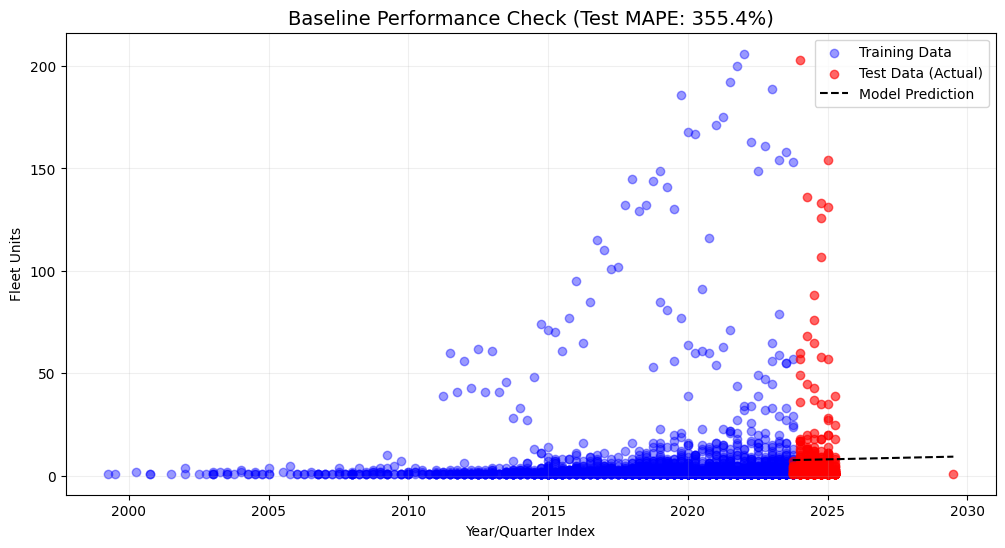

In [22]:
plt.figure(figsize=(12, 6))

# Plot History
plt.scatter(train_df['TIME_INDEX'], y_train, color='blue', alpha=0.4, label='Training Data')
# Plot Test (Actuals)
plt.scatter(test_df['TIME_INDEX'], y_test, color='red', alpha=0.6, label='Test Data (Actual)')
# Plot Test (Predictions)
plt.plot(test_df['TIME_INDEX'], test_preds, color='black', linestyle='--', label='Model Prediction')

plt.title(f'Baseline Performance Check (Test MAPE: {true_test_mape:.1f}%)', fontsize=14)
plt.xlabel('Year/Quarter Index')
plt.ylabel('Fleet Units')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Section 5 : Error visualization

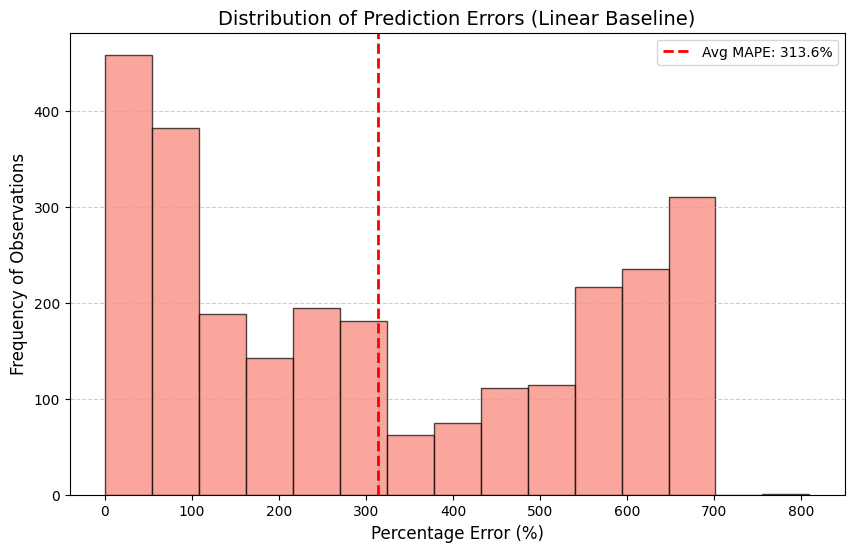

📉 The Baseline Linear Model has an average error of 313.59%.


In [23]:
from sklearn.metrics import mean_absolute_percentage_error

# 1. Calculate the Model's "In-Sample" Predictions
historical_preds = model_usage.predict(df_clean[['TIME_INDEX']].values)
historical_actuals = df_clean['USAGE_PROXY'].values

# 2. Compute MAPE
overall_mape = mean_absolute_percentage_error(historical_actuals, historical_preds) * 100

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Plotting the residual error distribution
errors = (abs(historical_actuals - historical_preds) / historical_actuals) * 100

plt.hist(errors, bins=15, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(overall_mape, color='red', linestyle='dashed', linewidth=2, label=f'Avg MAPE: {overall_mape:.1f}%')

plt.title('Distribution of Prediction Errors (Linear Baseline)', fontsize=14)
plt.xlabel('Percentage Error (%)', fontsize=12)
plt.ylabel('Frequency of Observations', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

print(f"📉 The Baseline Linear Model has an average error of {overall_mape:.2f}%.")